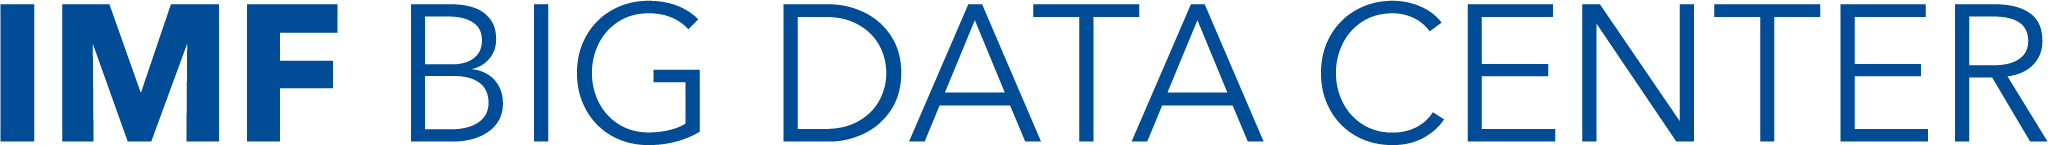

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/BDC_STI_26/blob/main/notebooks/BDC_GoogleTrends_extract.ipynb)

# Google Trends Extract

---

<br>**Contributors:**
<br> **Last update:**
<br> **Description:** This notebook extracts Google Trends search volume indexes for a list of countries and saves one file per country to Google Drive
<br> **References:**

In [ ]:
!pip install google-api-python-client

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 36.3 MB/s eta 0:00:00


In [ ]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import requests

from googleapiclient.discovery import build
from matplotlib.dates import DateFormatter
from getpass import getpass
import pycountry

In [ ]:
# Prompt user to input secret key (it will be hidden)
os.environ["MY_SECRET_KEY"] = getpass("Enter your secret key: ")


Enter your secret key: ··········


In [ ]:
api_key = os.environ["MY_SECRET_KEY"]

In [ ]:
API_KEY = api_key
os.environ['GOOGLE_TOKEN'] = API_KEY

In [ ]:
class Google():
    """
    Wrapper class for handling authentication and requests (GET) to Google API

    Parameters
    ----------
    token : str
        Google API token

    Notes
    -----
    For more information, please see https://developers.google.com/apis-explorer
    """

    def __init__(self, token=None):
        self.TOKEN = token if token else os.getenv("GOOGLE_TOKEN")

    @property
    def service(self):
        """Authenticate and instantiate Google API service"""
        return build('trends', 'v1beta', static_discovery=False, developerKey=self.TOKEN)

    def get(self, method, params):
        """Get result from Google API method"""
        return getattr(self.service, method)(**params).execute()


    def download(self, method, params):
        """Download result from Google API method"""

        if not method in ["getGraph", "getTimelinesForHealth"]:
            raise NotImplementedError("Method not supported.")

        result = self.get(method, params)

        df = pd.json_normalize(result["lines"], meta=["term"], record_path=["points"])

        params = "+".join([f"{k}={v}" for k, v in params.items()])
        name = f"{method}+{params}.csv"

        df.to_csv(name, index=False)

In [ ]:
google = Google()

# **Country List**

In [ ]:
#os.makedirs('travel_trends', exist_ok=True)

# List of countries
countries = [ 'Angola', 'Botswana', 'Burkina Faso', 'Burundi','Cameroon', "Côte d'Ivoire", 'Egypt', 'Ethiopia', 'Ghana','Kenya', 'Lesotho', 'Malawi',
    'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia','Nigeria', 'Rwanda', 'Senegal', 'Seychelles',
    'Somalia', 'South Africa', 'Tanzania', 'Togo', 'Tunisia','Uganda', 'Zambia', 'Zimbabwe', 'Latvia', 'Montenegro', 'Chad'
]


# Function to get ISO3 code
def get_iso3(country_name):
    try:
        # Fixes for names pycountry might not match exactly
        fixes = {
            'Congo': 'Congo, The Democratic Republic of the',
            #'Côte d’Ivoire': "Côte d’Ivoire",
            'Eswatini': 'Swaziland',
            'São Tomé and Príncipe': 'Sao Tome and Principe',
            'Cape Verde': 'Cabo Verde',
            'South Sudan': 'South Sudan'
        }
        lookup_name = fixes.get(country_name, country_name)
        return pycountry.countries.lookup(lookup_name).alpha_3
    except Exception as e:
        print(f"⚠️ Could not find ISO3 for {country_name}: {e}")
        return None

# Loop through countries
for country in countries:
    print(f"Fetching trends for {country}...")

    iso_code = get_iso3(country)
    if not iso_code:
        continue  # Skip if ISO code is not found

    # Set up filters
    filter_tourism = {
        'terms': [
            f'travel to {country}',
            f'visit {country}',
            f'trip to {country}',
            f'flight to {country}',
            f'hotels in {country}',
            f'apartments in {country}'
            f'airbnb {country}'
        ],
        'restrictions_startDate': '2010-01'
    }

    try:
        # Get the trend data
        r = google.get('getGraph', filter_tourism)

        # Create DataFrame
        df = pd.DataFrame(r["lines"][0]["points"])
        df["date"] = pd.to_datetime(df["date"])
        df = df.set_index("date")

        # Rename the value column to gti_tourism
        df.rename(columns={"value": "gti_tourism"}, inplace=True)

        # Save to Excel using ISO3 code
        #filename = f"travel_trends/{iso_code}_GTI.xlsx"
        filename = f"/content/drive/MyDrive/auto-download/data/GTI/{iso_code}.csv"
        df.to_csv(filename)
        print(f"✅ Saved to {filename}")

    except Exception as e:
        print(f"❌ Failed for {country} ({iso_code}): {e}")


Fetching trends for Angola...
✅ Saved to AGO.csv
Fetching trends for Botswana...
✅ Saved to BWA.csv
Fetching trends for Burkina Faso...
✅ Saved to BFA.csv
Fetching trends for Burundi...
✅ Saved to BDI.csv
Fetching trends for Cameroon...
✅ Saved to CMR.csv
Fetching trends for Côte d'Ivoire...
✅ Saved to CIV.csv
Fetching trends for Egypt...
✅ Saved to EGY.csv
Fetching trends for Ethiopia...
✅ Saved to ETH.csv
Fetching trends for Ghana...
✅ Saved to GHA.csv
Fetching trends for Kenya...
✅ Saved to KEN.csv
Fetching trends for Lesotho...
✅ Saved to LSO.csv
Fetching trends for Malawi...
✅ Saved to MWI.csv
Fetching trends for Mali...
✅ Saved to MLI.csv
Fetching trends for Mauritania...
✅ Saved to MRT.csv
Fetching trends for Mauritius...
✅ Saved to MUS.csv
Fetching trends for Morocco...
✅ Saved to MAR.csv
Fetching trends for Mozambique...
✅ Saved to MOZ.csv
Fetching trends for Namibia...
✅ Saved to NAM.csv
Fetching trends for Nigeria...
✅ Saved to NGA.csv
Fetching trends for Rwanda...
✅ Saved t

In [ ]:
for country in countries:
    iso_code = get_iso3(country)
    if not iso_code:
        continue

    filename = f"/content/drive/MyDrive/auto-download/data/GTI/GTI_{iso_code}.csv"

    if os.path.exists(filename):
        df = pd.read_csv(filename)
        df["date"] = pd.to_datetime(df["date"])
        df.set_index("date", inplace=True)

        plt.figure(figsize=(12, 6))
        df.plot(legend=False)
        plt.title(f"Search Volume for Travel to {country} ({iso_code})")
        plt.ylabel("Search Volume")
        plt.xlabel("Date")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"❌ File not found: {filename}")